# 패스트볼 무브먼트 계층적 군집분석 (Hierarchical Clustering)

**변수**: 체공시간 보정 수직 무브먼트(`ivb_ft`), 체공시간 보정 수평 무브먼트(`hb_ft`), 팔 각도(`arm_angle`)

**필요 데이터**: Google Drive의 원본 Statcast CSV → `data/raw/연도/statcast_YYYY-MM.csv`
(이 노트북은 `notebooks/` 폴더에서 실행하는 것을 기준으로 합니다.)

**방법**: 패스트볼(FF/SI/FC)만 가져온 뒤 **구종 이름표는 군집에 쓰지 않고**, 세 변수만으로 계층적 군집분석을 합니다.
군집이 끝난 뒤에만 원래 구종 이름표와 비교해서 "군집이 기존 분류와 얼마나 다른지" 확인합니다.

**분석 단위** (`UNIT` 설정):
- `"pitcher_season"` (기본): 투수 × 시즌 × 패스트볼 한 종류의 **평균값**을 점 하나로 사용
- `"pitch"`: 개별 투구를 무작위로 `SAMPLE_SIZE`개 뽑아서 사용

투구 전체(수백만 개)를 그대로 넣으면 계층적 군집분석은 메모리가 부족해서 돌아가지 않습니다.
(n개 점이면 거리 n²/2개를 계산해야 함 → 1만 개 ≈ 0.4GB, 10만 개 ≈ 40GB)

In [17]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 설정값 (필요하면 여기만 바꾸세요)
# -----------------------------
RAW_DIR = Path("../data/raw")              # 원본 데이터 (상대경로)
PROCESSED_DIR = Path("../data/processed")  # 결과 저장 위치

PITCH_TYPES = ["FF", "SI", "FC"]      # 체공시간 보정 대상 구종
TRAIN_YEARS = [2021, 2022, 2023, 2024, 2025]      # 구종별 기준 체공시간(T_ref) 계산 연도
CLUSTER_YEARS = [2021, 2022, 2023, 2024, 2025]  # 군집분석에 포함할 시즌
UNIT = "pitcher_season"               # "pitcher_season" 또는 "pitch"
MIN_PITCHES = 50                      # (pitcher_season) 투수-시즌-구종당 최소 투구 수
SAMPLE_SIZE = 8000                    # (pitch) 무작위로 뽑을 투구 수 (1만 이하 권장)
RANDOM_STATE = 42
N_CLUSTERS = 3                        # 최종 군집 수 (아래 덴드로그램/실루엣 보고 조정)

PLATE_Y_FT = 17.0 / 12.0
REFERENCE_Y_FT = 50.0
MIN_FLIGHT_TIME_S = 0.25
MAX_FLIGHT_TIME_S = 0.60

FEATURES = ["ivb_ft", "hb_ft", "arm_angle"]

## 1. 데이터 불러오기
119개 칼럼 중 필요한 칼럼만 읽어서 메모리를 아낍니다.

In [18]:
NEEDED = [
    "pitch_type", "game_year", "game_type", "description",
    "pitcher", "player_name", "p_throws",
    "pfx_x", "pfx_z", "release_pos_y", "vy0", "ay", "arm_angle",
]

files = sorted(RAW_DIR.glob("*/statcast_*.csv"))
print(f"CSV 파일 {len(files)}개 발견")
if not files:
    raise FileNotFoundError("data/raw/ 안에 CSV가 없습니다. 노트북이 notebooks/ 폴더에 있는지 확인하세요.")

frames = []
for f in files:
    part = pd.read_csv(f, usecols=lambda c: c in NEEDED, low_memory=False)
    frames.append(part[part["pitch_type"].isin(PITCH_TYPES)])
data = pd.concat(frames, ignore_index=True)
del frames

missing = set(NEEDED) - set(data.columns)
if missing:
    raise KeyError(f"필수 칼럼이 없습니다: {sorted(missing)}")

for col in ["pfx_x", "pfx_z", "release_pos_y", "vy0", "ay", "arm_angle", "game_year"]:
    data[col] = pd.to_numeric(data[col], errors="coerce")

print(f"FF/SI/FC 투구 수: {len(data):,}")
data.groupby("game_year").size()

CSV 파일 42개 발견
FF/SI/FC 투구 수: 1,970,724


game_year
2021    431197
2022    421148
2023    419124
2024    349232
2025    350023
dtype: int64

## 2. 품질 필터
정규시즌만, 피치아웃 제외, 필요한 값이 비어 있는 투구 제외.

In [19]:
before = len(data)
data = data[
    (data["game_type"] == "R")
    & (data["description"] != "pitchout")
    & data["p_throws"].isin(["R", "L"])
].dropna(subset=["pfx_x", "pfx_z", "release_pos_y", "vy0", "ay", "arm_angle"])
print(f"{before:,} → {len(data):,} 투구")

1,970,724 → 1,842,344 투구


## 3. 체공시간 보정 무브먼트 계산 (가이드 문서 1~9단계)

- `IVB_raw = 12 × pfx_z`, `HB_arm = 12 × s × pfx_x` (우투 s=−1, 좌투 s=+1 → 암사이드가 +)
- 체공시간 `T = t(홈플레이트) − t(릴리스)`, y(t) = 50 + vy0·t + ½·ay·t²
- `T_ref` = 2021–2023 구종별 T 중앙값
- 보정값 = 원 무브먼트 × (T_ref / T)²

In [20]:
def time_at_y(vy0, ay, target_y, reference_y=50.0):
    """Statcast y=50ft 기준 궤적에서 target_y에 도달하는 시각 (t=0에 가까운 근)."""
    vy, accel, target = np.broadcast_arrays(
        np.asarray(vy0, float), np.asarray(ay, float), np.asarray(target_y, float)
    )
    c = reference_y - target
    disc = vy**2 - 2.0 * accel * c
    result = np.full(vy.shape, np.nan)

    ok = np.isfinite(vy) & np.isfinite(accel) & np.isfinite(target) & (disc >= 0)

    linear = ok & np.isclose(accel, 0.0) & (vy != 0)
    result[linear] = -c[linear] / vy[linear]

    quad = ok & ~np.isclose(accel, 0.0)
    sq = np.sqrt(np.where(quad, disc, np.nan))
    with np.errstate(divide="ignore", invalid="ignore"):
        r1 = (-vy - sq) / accel
        r2 = (-vy + sq) / accel
    nearest = np.where(np.abs(r1) <= np.abs(r2), r1, r2)
    result[quad] = nearest[quad]
    return result


# 원 무브먼트 (inch)
data["ivb_raw_inches"] = data["pfx_z"] * 12.0
hand = data["p_throws"].map({"R": -1.0, "L": 1.0})
data["hb_arm_side_inches"] = data["pfx_x"] * 12.0 * hand

# 체공시간
t_release = time_at_y(data["vy0"], data["ay"], data["release_pos_y"], REFERENCE_Y_FT)
t_plate = time_at_y(data["vy0"], data["ay"], PLATE_Y_FT, REFERENCE_Y_FT)
data["flight_time_s"] = t_plate - t_release
data = data[data["flight_time_s"].between(MIN_FLIGHT_TIME_S, MAX_FLIGHT_TIME_S)]

# 구종별 기준 체공시간 (학습연도에서만 계산해서 고정)
reference_times = (
    data[data["game_year"].isin(TRAIN_YEARS)]
    .groupby("pitch_type")["flight_time_s"].median()
)
lost = set(PITCH_TYPES) - set(reference_times.index)
if lost:
    raise ValueError(f"기준 체공시간을 못 구한 구종: {sorted(lost)} (TRAIN_YEARS 데이터가 있는지 확인)")
print("구종별 기준 체공시간(초)")
print(reference_times.round(4))

# 보정
data["reference_flight_time_s"] = data["pitch_type"].map(reference_times)
data["flight_time_scale"] = (data["reference_flight_time_s"] / data["flight_time_s"]) ** 2
data["ivb_ft"] = data["ivb_raw_inches"] * data["flight_time_scale"]
data["hb_ft"] = data["hb_arm_side_inches"] * data["flight_time_scale"]

data[["pitch_type", "p_throws", "flight_time_s", "flight_time_scale", "ivb_ft", "hb_ft", "arm_angle"]].describe().round(3)

구종별 기준 체공시간(초)
pitch_type
FC    0.4221
FF    0.3997
SI    0.4031
Name: flight_time_s, dtype: float64


,flight_time_s,flight_time_scale,ivb_ft,hb_ft,arm_angle
count,1842341.000,1842341.000,1842341.000,1842341.000,1842341.000
mean,0.404,1.001,12.740,8.232,38.992
std,0.015,0.063,5.441,6.497,13.037
min,0.352,0.463,-15.123,-20.335,-70.700
25%,0.394,0.961,9.019,4.106,32.200
50%,0.403,1.000,13.856,8.654,40.100
75%,0.412,1.040,16.911,13.233,47.300
max,0.587,1.382,32.956,31.012,84.500


### 계산 점검 (가이드 23절)
- 체공시간 대부분 0.35~0.50초인지
- 보정배율이 1 근처인지
- 패스트볼 `hb_ft` 평균이 (특히 SI) 양수, 즉 암사이드인지

In [21]:
print("체공시간 0.35~0.50초 비율:", round(data["flight_time_s"].between(0.35, 0.50).mean(), 3))
data.groupby(["pitch_type", "p_throws"])[["flight_time_s", "flight_time_scale", "ivb_ft", "hb_ft"]].mean().round(2)

체공시간 0.35~0.50초 비율: 1.0


flight_time_s  flight_time_scale  ivb_ft  hb_ft
pitch_type p_throws                                                 
FC         L                  0.43               0.96    7.24  -1.72
           R                  0.42               1.02    8.42  -2.57
FF         L                  0.40               0.98   15.49   7.60
           R                  0.40               1.01   16.12   7.54
SI         L                  0.41               0.98    8.51  14.76
           R                  0.40               1.01    8.04  15.00

## 4. 군집에 넣을 점 만들기
구종(`pitch_type`)은 투수가 던진 패스트볼 종류를 구분해서 평균내는 데만 쓰고, **군집 변수에는 넣지 않습니다.**

In [22]:
pool = data[data["game_year"].isin(CLUSTER_YEARS)]

if UNIT == "pitcher_season":
    target = (
        pool.groupby(["pitcher", "player_name", "p_throws", "game_year", "pitch_type"])
        .agg(
            n_pitches=("ivb_ft", "size"),
            ivb_ft=("ivb_ft", "mean"),
            hb_ft=("hb_ft", "mean"),
            arm_angle=("arm_angle", "mean"),
        )
        .reset_index()
    )
    target = target[target["n_pitches"] >= MIN_PITCHES].reset_index(drop=True)
elif UNIT == "pitch":
    target = (
        pool.sample(n=min(SAMPLE_SIZE, len(pool)), random_state=RANDOM_STATE)
        [["pitcher", "player_name", "p_throws", "game_year", "pitch_type"] + FEATURES]
        .reset_index(drop=True)
    )
else:
    raise ValueError('UNIT은 "pitcher_season" 또는 "pitch"만 가능합니다.')

print(f"군집에 넣을 점: {len(target):,}개")
if len(target) > 15000:
    print("⚠️ 점이 너무 많아 메모리가 부족할 수 있습니다. MIN_PITCHES를 올리거나 SAMPLE_SIZE를 줄이세요.")
target["pitch_type"].value_counts()

군집에 넣을 점: 5,581개


pitch_type
FF    2900
SI    1735
FC     946
Name: count, dtype: int64

## 5. 표준화 + 계층적 군집 (Ward)
무브먼트(inch)와 팔 각도(도)는 단위가 달라서, 표준화(평균 0, 표준편차 1)를 해야 한 변수가 거리를 독점하지 않습니다.

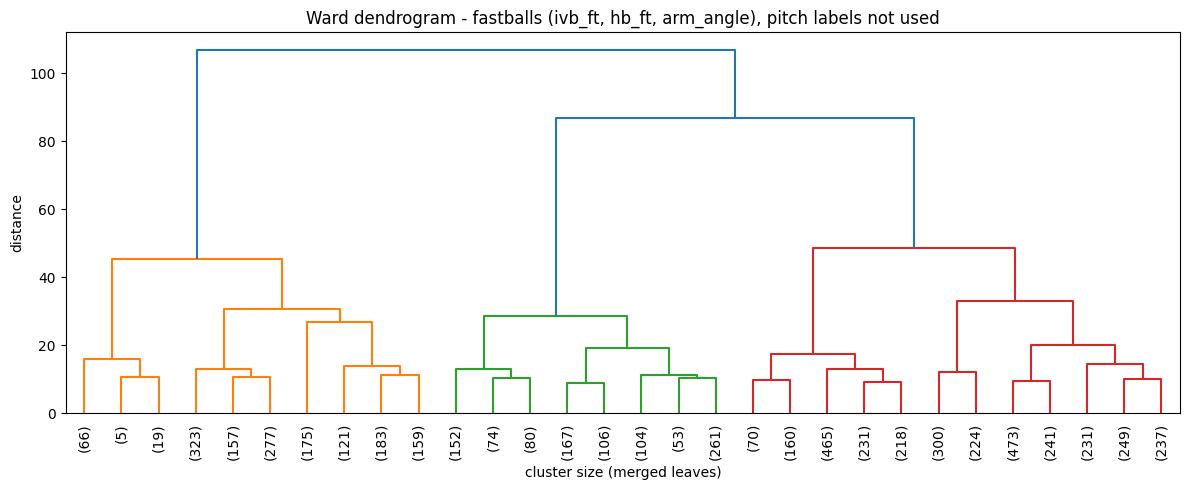

In [23]:
X = StandardScaler().fit_transform(target[FEATURES])
Z = linkage(X, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90)
plt.title("Ward dendrogram - fastballs (ivb_ft, hb_ft, arm_angle), pitch labels not used")
plt.xlabel("cluster size (merged leaves)")
plt.ylabel("distance")
plt.tight_layout()
plt.show()

## 6. 군집 수 고르기 (실루엣 점수)
높을수록 군집이 잘 나뉜 것. 덴드로그램에서 큰 간격이 생기는 지점과 같이 보고 `N_CLUSTERS`를 정하세요.

In [24]:
scores = {}
for k in range(2, 11):
    labels_k = fcluster(Z, t=k, criterion="maxclust")
    scores[k] = silhouette_score(X, labels_k)

pd.Series(scores, name="silhouette").round(3).to_frame().T

,2,3,4,5,6,7,8,9,10
silhouette,0.359,0.412,0.309,0.317,0.311,0.301,0.281,0.29,0.246


## 7. 최종 군집 결과

In [25]:
target["cluster"] = fcluster(Z, t=N_CLUSTERS, criterion="maxclust")

summary = (
    target.groupby("cluster")
    .agg(
        n=("pitcher", "size"),
        ivb_ft=("ivb_ft", "mean"),
        hb_ft=("hb_ft", "mean"),
        arm_angle=("arm_angle", "mean"),
    )
    .round(2)
)
summary

,n,ivb_ft,hb_ft,arm_angle
cluster,,,,
1,1485,7.27,15.02,26.22
2,997,7.80,-1.87,38.67
3,3099,15.64,8.26,43.36


### 군집 vs 원래 구종 이름표
군집에는 구종 이름표를 안 썼기 때문에, 여기서 처음으로 비교합니다.
한 군집에 여러 구종이 섞여 있으면 "이름은 다르지만 실제 움직임은 비슷한 공"이라는 뜻입니다.

In [26]:
# 각 군집 안에서 구종 비율 (%)
(pd.crosstab(target["cluster"], target["pitch_type"], normalize="index") * 100).round(1)

pitch_type,FC,FF,SI
cluster,,,
1,0.3,16.4,83.3
2,90.6,9.3,0.1
3,1.3,82.7,16.0


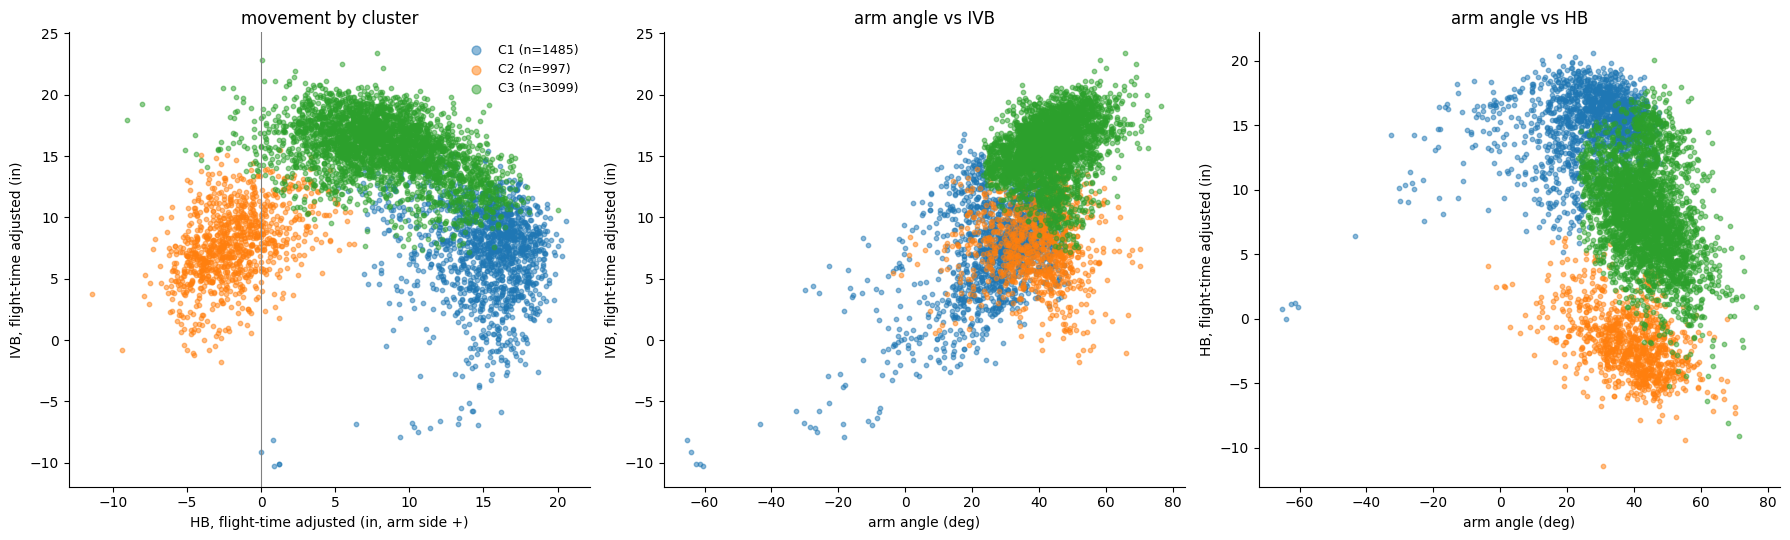

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
cmap = plt.get_cmap("tab10")
markers = {"FF": "o", "SI": "s", "FC": "^"}

for i, (c, g) in enumerate(target.groupby("cluster")):
    axes[0].scatter(g["hb_ft"], g["ivb_ft"], s=10, alpha=0.5, color=cmap(i), label=f"C{c} (n={len(g)})")
    axes[1].scatter(g["arm_angle"], g["ivb_ft"], s=10, alpha=0.5, color=cmap(i))
    axes[2].scatter(g["arm_angle"], g["hb_ft"], s=10, alpha=0.5, color=cmap(i))

axes[0].set_xlabel("HB, flight-time adjusted (in, arm side +)")
axes[0].set_ylabel("IVB, flight-time adjusted (in)")
axes[0].set_title("movement by cluster")
axes[0].axvline(0, color="grey", lw=0.8)
axes[0].legend(frameon=False, fontsize=9, markerscale=2)

axes[1].set_xlabel("arm angle (deg)")
axes[1].set_ylabel("IVB, flight-time adjusted (in)")
axes[1].set_title("arm angle vs IVB")

axes[2].set_xlabel("arm angle (deg)")
axes[2].set_ylabel("HB, flight-time adjusted (in)")
axes[2].set_title("arm angle vs HB")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

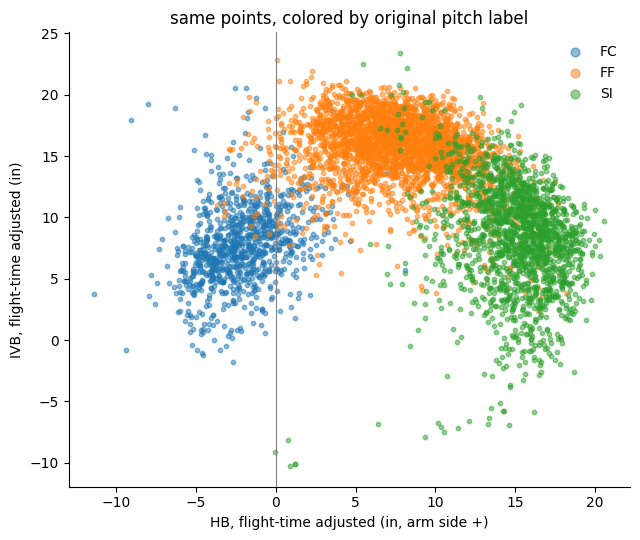

In [28]:
# 비교용: 같은 점을 '원래 구종 이름표'로 색칠
fig, ax = plt.subplots(figsize=(6.5, 5.5))
for i, (pt, g) in enumerate(target.groupby("pitch_type")):
    ax.scatter(g["hb_ft"], g["ivb_ft"], s=10, alpha=0.5, color=cmap(i), label=pt)
ax.set_xlabel("HB, flight-time adjusted (in, arm side +)")
ax.set_ylabel("IVB, flight-time adjusted (in)")
ax.set_title("same points, colored by original pitch label")
ax.axvline(0, color="grey", lw=0.8)
ax.legend(frameon=False, markerscale=2)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 군집별 예시 (pitcher_season이면 투구 수 많은 순)

In [29]:
sort_col = "n_pitches" if "n_pitches" in target.columns else "ivb_ft"
cols = ["cluster", "player_name", "game_year", "pitch_type"] + (["n_pitches"] if "n_pitches" in target.columns else []) + FEATURES
(
    target.sort_values(sort_col, ascending=False)
    .groupby("cluster").head(5)[cols]
    .sort_values(["cluster", sort_col], ascending=[True, False])
    .round(2)
)

,cluster,player_name,game_year,pitch_type,n_pitches,ivb_ft,hb_ft,arm_angle
2352,1,"Manaea, Sean",2021,SI,1693,12.27,13.97,31.51
3723,1,"Valdez, Framber",2022,SI,1502,6.96,14.12,43.53
2161,1,"Castillo, Luis",2023,FF,1419,13.71,12.12,20.10
3609,1,"Singer, Brady",2023,SI,1294,9.40,13.12,28.85
3608,1,"Singer, Brady",2022,SI,1278,10.67,15.19,31.25
4160,2,"Burnes, Corbin",2022,FC,1807,13.09,-4.98,39.58
4162,2,"Burnes, Corbin",2023,FC,1705,12.83,-3.56,42.50
3136,2,"Steele, Justin",2023,FF,1619,10.35,-1.21,46.33
4158,2,"Burnes, Corbin",2021,FC,1348,12.90,-4.83,40.01
4066,2,"Ashcraft, Graham",2023,FC,1217,7.72,-2.32,49.33


## 8. 결과 저장
`data/processed/`에 저장합니다. (원본 `data/raw/`는 수정하지 않음)

In [30]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
out_path = PROCESSED_DIR / f"hclust_fastballs_{UNIT}.csv"
target.to_csv(out_path, index=False)
print("저장 완료:", out_path.name)

저장 완료: hclust_fastballs_pitcher_season.csv
